# L2: LLM Inference Fundamentals

In this notebook, you'll build a working understanding of how LLMs generate text token by token and why a KV cache avoids repeatedly evaluating the model for earlier token positions.

## Learning Objectives

1. **Tokenization** - See how text maps to token IDs, the model's actual input
2. **Autoregressive generation** - Implement the decode loop from scratch
3. **Attention mechanism** - Translate the Q K^T / sqrt(d_k) formula directly into code
4. **KV cache** - Compare cached and uncached decoding on a CUDA GPU

## 1. Setup

Standard imports — PyTorch, our model wrapper, and two decode functions we'll compare: one without caching, one with.

<div style="background-color: #172033; color: #f0f4f8; padding: 15px; border-left: 4px solid #58a6ff; border-radius: 5px; margin: 10px 0;">

Helper code is split by responsibility:

- `tiny_llm.py` owns GPU model loading plus raw forward passes with and without a KV cache.
- `helper.py` owns sampling, autoregressive decode loops, and tokenization display.

The attention implementation stays in this notebook so you can connect the formula directly to executable code.

</div>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
import torch
import torch.nn.functional as F
from torch import Tensor

from helper import (
    TinyLLM,
    auto_regressive_decode,
    auto_regressive_decode_with_kv_cache,
    demo_tokenization,
)

In [2]:
from pathlib import Path
import sglang

local_model_path = Path("../models/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B")
model_path = (
    str(local_model_path)
    if local_model_path.exists()
    else "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
)
input_text = "SGLang is a fast inference engine for"
max_new_tokens = 16

print(f"SGLang: {sglang.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Model: {model_path}")

SGLang: 0.5.20
GPU: NVIDIA GB10
Model: deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B


## 2. Load Model

DeepSeek-R1-Distill-Qwen has 1.5B parameters. The model is small enough for this lab, but its attention and KV-cache mechanics also apply to much larger decoder-only models.

The `TinyLLM` implementation is in `tiny_llm.py`. It loads BF16 weights on CUDA and exposes separate raw forward methods for cached and uncached decoding.

In [28]:
tiny_llm = TinyLLM(model_path)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded on cuda:0
GPU memory: 7.14 GB allocated, 7.37 GB reserved


## 3. Baseline Generation

HuggingFace's built-in `generate()` uses KV cache by default. We run it first to get the reference output — everything we build must match this exactly.

You'll use this to verify that caching doesn't change what the model produces, only how efficiently it gets there.


In [29]:
# Baseline: HuggingFace generate() with KV cache enabled by default
output_text_std = tiny_llm.generate_std(
    input_text, max_new_tokens, temperature=0
)

print(f"Input:  \"{input_text}\"")
print(f"Output: \"{output_text_std}\"")
print(
    "\nThis is our ground truth"
    " — every implementation must match this exactly."
)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Input:  "SGLang is a fast inference engine for"
Output: "SGLang is a fast inference engine for deep learning. It's designed to be efficient in terms of memory usage and computation"

This is our ground truth — every implementation must match this exactly.


## 4. Tokenization

What does the model actually see as input? The tokenizer splits text into subword units, not whole words. Note how many input tokens we get — that number comes back when we count operations.

In [9]:
# See how the tokenizer splits our input into subword units
token_ids = demo_tokenization(tiny_llm, input_text)
initial_tokens = len(token_ids)
print(f"\n{initial_tokens} input tokens — remember this number for later.")

Tokens: ['S', 'GL', 'ang', 'Ġis', 'Ġa', 'Ġfast', 'Ġinference', 'Ġengine', 'Ġfor']
Token IDs: [50, 3825, 524, 374, 264, 4937, 44378, 4712, 369]

9 input tokens — remember this number for later.


## 5. Custom Attention

In the slides, we saw the attention formula:    
**Attention(Q, K, V) = softmax(Q K^T / √d_k) · V**

Now we translate that formula directly into code:
- `_attention_impl`: The core computation — Q·K^T scaled, causal mask, softmax, multiply by V
- `simple_causal_attention`: A wrapper that handles **GQA** (Grouped Query Attention), where multiple query heads share the same K/V heads — this is how DeepSeek, Llama, and most modern models reduce KV cache memory

In [10]:
def _attention_impl(
    q: Tensor, k: Tensor, v: Tensor,
    scale: float, mask: Tensor
):
    """Core: softmax(Q @ K^T / sqrt(d_k)) @ V"""
    # Q @ K^T — attention scores for every (query, key) pair
    scores = torch.matmul(q, k.transpose(-2, -1)) * scale
    # Causal mask — future positions become -inf, then 0 after softmax
    scores = scores.masked_fill(~mask, float("-inf"))
    # Normalize to attention weights
    probs = torch.softmax(scores, dim=-1)
    # Weighted sum of values
    return torch.matmul(probs, v)

In [32]:
def simple_causal_attention(
    query: Tensor, key: Tensor, value: Tensor,
    **kwargs
):
    """Educational causal attention with GQA support."""
    _ = kwargs
    head_dim = query.shape[-1]
    scale = 1.0 / (head_dim**0.5)

    # GQA: multiple query heads share each K/V head.
    if query.shape[1] % key.shape[1] != 0:
        raise ValueError("Query heads must be divisible by KV heads.")
    gqa_group_size = query.shape[1] // key.shape[1]
    key = key.repeat_interleave(gqa_group_size, dim=1)
    value = value.repeat_interleave(gqa_group_size, dim=1)

    query_float = query.float()
    key_float = key.float()
    value_float = value.float()

    # Bottom-right causal alignment also works when a cached query is
    # shorter than the key/value sequence.
    query_length = query_float.shape[-2]
    key_length = key_float.shape[-2]
    query_positions = torch.arange(
        key_length - query_length, key_length, device=query.device
    )
    key_positions = torch.arange(key_length, device=query.device)
    mask = key_positions[None, :] <= query_positions[:, None]
    mask = mask[None, None, :, :]

    output = _attention_impl(
        query_float, key_float, value_float, scale, mask
    )
    return output.to(dtype=query.dtype)

We then **monkey-patch** PyTorch's `F.scaled_dot_product_attention` — that just means swapping out the function at runtime so every layer in the model runs our code instead of the built-in CUDA kernels. Slower, but lets us verify our math is correct.

In [33]:
# Swap PyTorch's attention with ours — every layer now runs our code
_orig_sdp = F.scaled_dot_product_attention
F.scaled_dot_product_attention = simple_causal_attention

try:
    torch.cuda.synchronize()
    tic = time.perf_counter()
    text_monkey_patch = auto_regressive_decode(
        tiny_llm, input_text,
        max_new_tokens, temperature=0.0
    )
    torch.cuda.synchronize()
    toc = time.perf_counter()
finally:
    F.scaled_dot_product_attention = _orig_sdp

print(f"Output: \"{text_monkey_patch}\"")
tok_per_sec = max_new_tokens / (toc - tic)
print(f"Time:   {toc - tic:.2f}s ({tok_per_sec:.1f} tok/s)")
match = text_monkey_patch == output_text_std
print(f"Match:  {'Yes' if match else 'MISMATCH!'}")

Output: "SGLang is a fast inference engine for deep learning. It's designed to be efficient in terms of memory usage and computation"
Time:   0.39s (40.5 tok/s)
Match:  Yes


## 6. KV Cache Comparison

In a causal model, the K and V tensors already computed for the existing prefix do not change during later decode steps. Generation therefore has two phases:

- **Prefill**: Process the full prompt in parallel and retain its K/V tensors.
- **Decode**: Process one new token position and reuse the cached prefix at each step.

This reduces repeated token-position evaluations. Attention for each new query must still read the growing cached prefix, so the cache changes total attention work from cubic to quadratic rather than eliminating sequence-length cost.

### Without KV Cache (naive)

This is the "without" case from the slides — every step feeds the entire sequence from scratch. Token "sat" recomputes "The" and "cat" even though their K and V haven't changed.

In [34]:
# Naive: recompute the complete sequence at every decode step.
torch.cuda.synchronize()
tic = time.perf_counter()
text_no_cache = auto_regressive_decode(
    tiny_llm, input_text,
    max_new_tokens, temperature=0.0
)
torch.cuda.synchronize()
toc = time.perf_counter()
time_no_cache = toc - tic

assert text_no_cache == output_text_std

# Token-position evaluations across all model forward passes.
total_ops = sum(
    initial_tokens + step for step in range(max_new_tokens)
)

print(f"Output: \"{text_no_cache}\"")
tok_s = max_new_tokens / time_no_cache
print(f"Time:   {time_no_cache:.2f}s ({tok_s:.1f} tok/s)")
print(f"Token-position evaluations: {total_ops}")

Output: "SGLang is a fast inference engine for deep learning. It's designed to be efficient in terms of memory usage and computation"
Time:   0.33s (48.6 tok/s)
Token-position evaluations: 264


### With KV Cache (optimized)

Prefill evaluates every prompt position once. Each decode step then evaluates only the newest position while attending to K/V tensors retained from the prefix. Greedy decoding must produce the same tokens as the uncached path.

In [35]:
# Optimized: prefill once, then evaluate one new position per step.
torch.cuda.synchronize()
tic = time.perf_counter()
text_kv_cache = auto_regressive_decode_with_kv_cache(
    tiny_llm, input_text,
    max_new_tokens, temperature=0.0
)
torch.cuda.synchronize()
toc = time.perf_counter()
time_with_cache = toc - tic

assert text_kv_cache == output_text_std

# Prompt prefill plus one position for each remaining decode step.
total_ops_kv = initial_tokens + (max_new_tokens - 1)
speedup = time_no_cache / time_with_cache

print(f"Output: \"{text_kv_cache}\"")
tok_s = max_new_tokens / time_with_cache
print(f"Time:   {time_with_cache:.2f}s ({tok_s:.1f} tok/s)")
print(f"Token-position evaluations: {total_ops_kv}")
print("\n--- Comparison ---")
print(
    f"Evaluations: {total_ops} -> {total_ops_kv}"
    f" ({total_ops / total_ops_kv:.1f}x fewer)"
)
print(f"Wall-clock speedup: {speedup:.2f}x")

Output: "SGLang is a fast inference engine for deep learning. It's designed to be efficient in terms of memory usage and computation"
Time:   0.33s (48.8 tok/s)
Token-position evaluations: 24

--- Comparison ---
Evaluations: 264 -> 24 (11.0x fewer)
Wall-clock speedup: 1.00x


### Visualization

The slides showed the conceptual difference — without cache, each step reprocesses the whole history; with cache, only the new token. Here's that same idea in numbers.

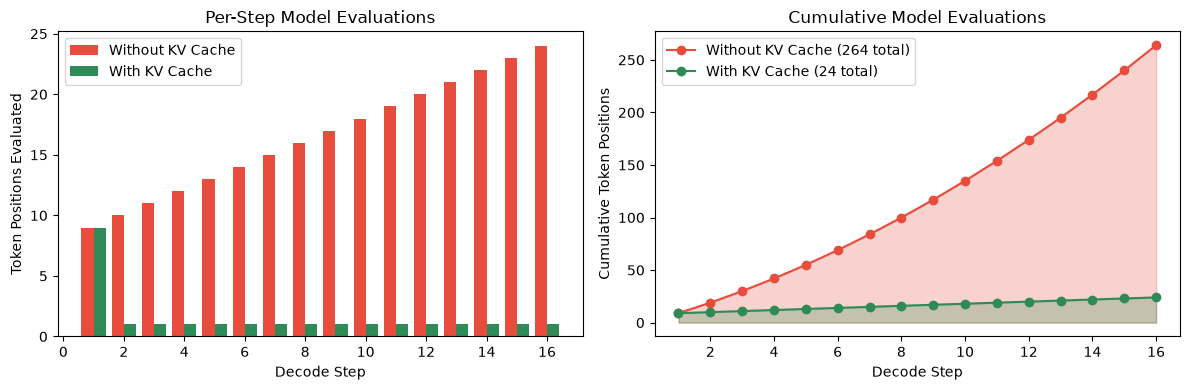

In [36]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(1, max_new_tokens + 1)
ops_no_cache = [initial_tokens + step for step in range(max_new_tokens)]
ops_kv_cache = [initial_tokens] + [1] * (max_new_tokens - 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(
    steps - 0.2, ops_no_cache, 0.4,
    label="Without KV Cache", color="#e74c3c",
)
ax1.bar(
    steps + 0.2, ops_kv_cache, 0.4,
    label="With KV Cache", color="#2e8b57",
)
ax1.set(
    xlabel="Decode Step",
    ylabel="Token Positions Evaluated",
    title="Per-Step Model Evaluations",
)
ax1.legend()

cumulative_no_cache = np.cumsum(ops_no_cache)
cumulative_kv_cache = np.cumsum(ops_kv_cache)
ax2.fill_between(steps, cumulative_no_cache, alpha=0.25, color="#e74c3c")
ax2.fill_between(steps, cumulative_kv_cache, alpha=0.25, color="#2e8b57")
ax2.plot(
    steps, cumulative_no_cache, "o-", color="#e74c3c",
    label=f"Without KV Cache ({total_ops} total)",
)
ax2.plot(
    steps, cumulative_kv_cache, "o-", color="#2e8b57",
    label=f"With KV Cache ({total_ops_kv} total)",
)
ax2.set(
    xlabel="Decode Step",
    ylabel="Cumulative Token Positions",
    title="Cumulative Model Evaluations",
)
ax2.legend()

plt.tight_layout()
plt.show()

**Key takeaway:** A KV cache stores each layer's K/V tensors and reuses them. In this run, token-position evaluations drop from 264 to 24. The short 16-token benchmark may remain dominated by kernel-launch and Python overhead, so operation reduction does not guarantee a visible wall-clock speedup at this scale.

**Next lesson:** KV caching helps within one request. Prefix caching extends the idea across requests that share prompt prefixes.